# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import jarque_bera
import seaborn as sns

from src.config import INTERIM_DATA_DIR

In [23]:
# Load the dataset
df = pd.read_parquet(INTERIM_DATA_DIR / "dataset.parquet")
df_sentiment_result = pd.read_parquet(INTERIM_DATA_DIR / "df_sentiment_result.parquet")

# The Integrity & Sanity Check

In [24]:
df.sample(10)

,video_id,title,video_format,content_pillar,publish_year,publish_month,video_age_cohort,video_age_days,lifetime_engagement_rate,marginal_engagement_rate,daily_view_velocity,positive_sentiment_percentage
1443,Kw4UHNnilPY,[Stray Kids : SKZ-TALKER GO! Season 5] Ep.19 A...,Long-form,SKZ-TALKER GO!,2025,7,Catalog (6-24 Months),326,0.108575,0.022172,363.808152,90.099010
1693,GTGdRFRabDo,#현진 의 #락챌린지 #LALALALA_Challenge 🤘 w/ #ITZY #YE...,Short,ROCK-STAR Era,2024,1,Legacy (2+ Years),879,0.114684,0.063531,2357.537561,95.081967
1011,0im5OGhn5_c,"Stray Kids ""神메뉴(God's Menu)"" Dance Practice Vi...",Long-form,Dance & Performance,2020,12,Legacy (2+ Years),2006,0.098703,0.035761,470.394080,59.340659
1332,uwLBNkJ1bY4,"Stray Kids ""CEREMONY"" Dance Practice Video (Ma...",Long-form,Dance & Performance,2025,8,Catalog (6-24 Months),290,0.079381,0.017581,2576.405639,90.789474
1848,fsp7O-XIly0,"Stray Kids ""MAXIDENT"" Album Unboxing",Long-form,Other/Music Videos,2022,10,Legacy (2+ Years),1346,0.137602,0.043478,131.611003,72.500000
240,JVM65SjoZSw,"Stray Kids ""ESCAPE (Bang Chan & Hyunjin)"" Vide...",Long-form,Making Film,2025,3,Catalog (6-24 Months),440,0.138556,0.044607,349.295786,87.096774
523,Y5yvC_NEjT4,[SPOT KIDS : BLACK] 긴박한 현장의 Stray Kids와 명사수 현진!,Long-form,SPOT KIDS,2018,1,Legacy (2+ Years),3074,0.153716,0.105820,52.120450,67.142857
964,HiMJR4SZ2r0,[Two Kids Room(투키즈룸)] VOL.5 Ep.07 Bang Chan X ...,Long-form,Kids Room Series,2019,11,Legacy (2+ Years),2414,0.095176,0.072254,35.780879,60.294118
379,GWSH0W3IcYs,[SKZ VLOG] I.N : I.N의 퐁당로그 9 in Busan & London,Long-form,Vlogs & Logs,2025,4,Catalog (6-24 Months),422,0.129799,0.032765,287.213312,74.766355
600,Vu23Rnu6SzU,[SKZ VLOG] Changbin : 돼끼의 꿀로그,Long-form,Vlogs & Logs,2020,8,Legacy (2+ Years),2134,0.163535,0.049505,45.260714,75.308642


In [25]:
df_sentiment_result.sample(5)

,video_id,comment_id,text,language,sentiment_label
143360,dR9HdopWZzI,UgypJOtyS6jmFe26aeZ4AaABAg,"Changbin rocked it, you dance beautifully, you...",eng_Latn,positive
152123,qfbEDtYuaEA,UgyURa_03yvq-btxdm94AaABAg,Their footsteps about to cause an earthquake i...,eng_Latn,positive
127167,uL47tVkagHg,UgyfWFyPVegZTqZYYph4AaABAg,When there is no English captions so you just ...,eng_Latn,positive
179223,fs9zzKkeyuE,UgzEvFV5h3ETS-yC28h4AaABAg,WHY IS NOBODY TALKING ABOUT HOW GOOD MINHO LOO...,eng_Latn,positive
123412,QIoHz-ZD9WQ,Ugydnnjh5PWhmQTuAv54AaABAg,당신은 정말 대단해요,kor_Hang,positive


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2086 entries, 0 to 2085
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   video_id                       2086 non-null   str     
 1   title                          2086 non-null   str     
 2   video_format                   2086 non-null   category
 3   content_pillar                 2086 non-null   category
 4   publish_year                   2086 non-null   uint16  
 5   publish_month                  2086 non-null   uint8   
 6   video_age_cohort               2086 non-null   category
 7   video_age_days                 2086 non-null   uint16  
 8   lifetime_engagement_rate       2086 non-null   float64 
 9   marginal_engagement_rate       2086 non-null   float64 
 10  daily_view_velocity            2086 non-null   float64 
 11  positive_sentiment_percentage  2079 non-null   float64 
dtypes: category(3), float64(4), str(2), uint16(2)

In [27]:
df_sentiment_result.groupby("video_id")["text"].count().sort_values(ascending=False)

video_id
jrjmw5uPjyY    324
F0UIsSnotlA    285
l8sSQAa1kNM    284
Oswujxm2Ag0    255
IxMAU-t_0tw    234
              ... 
N4TvZEitC-0     62
dlFM8CI2wjM     62
JWh7gr-e84k     61
PSdAXuUDNpo     59
zTkwIgT64ow     57
Name: text, Length: 2079, dtype: int64

In [28]:
# 1. Check for missing values or infinite numbers
print("Missing Values:")
print(df.isnull().sum())

print("\nInfinite Numbers: ")
print(df.isin([np.inf, -np.inf]).sum())

Missing Values:
video_id                         0
title                            0
video_format                     0
content_pillar                   0
publish_year                     0
publish_month                    0
video_age_cohort                 0
video_age_days                   0
lifetime_engagement_rate         0
marginal_engagement_rate         0
daily_view_velocity              0
positive_sentiment_percentage    7
dtype: int64

Infinite Numbers: 
video_id                         0
title                            0
video_format                     0
content_pillar                   0
publish_year                     0
publish_month                    0
video_age_cohort                 0
video_age_days                   0
lifetime_engagement_rate         0
marginal_engagement_rate         0
daily_view_velocity              0
positive_sentiment_percentage    0
dtype: int64


***Note:*** Missing values are present in Column `positive_sentiment_percentage` due to the fact that some videos have no comments. Thus, further analysis are not needed to be done on those videos.

# Univariate Analysis
## Distribution

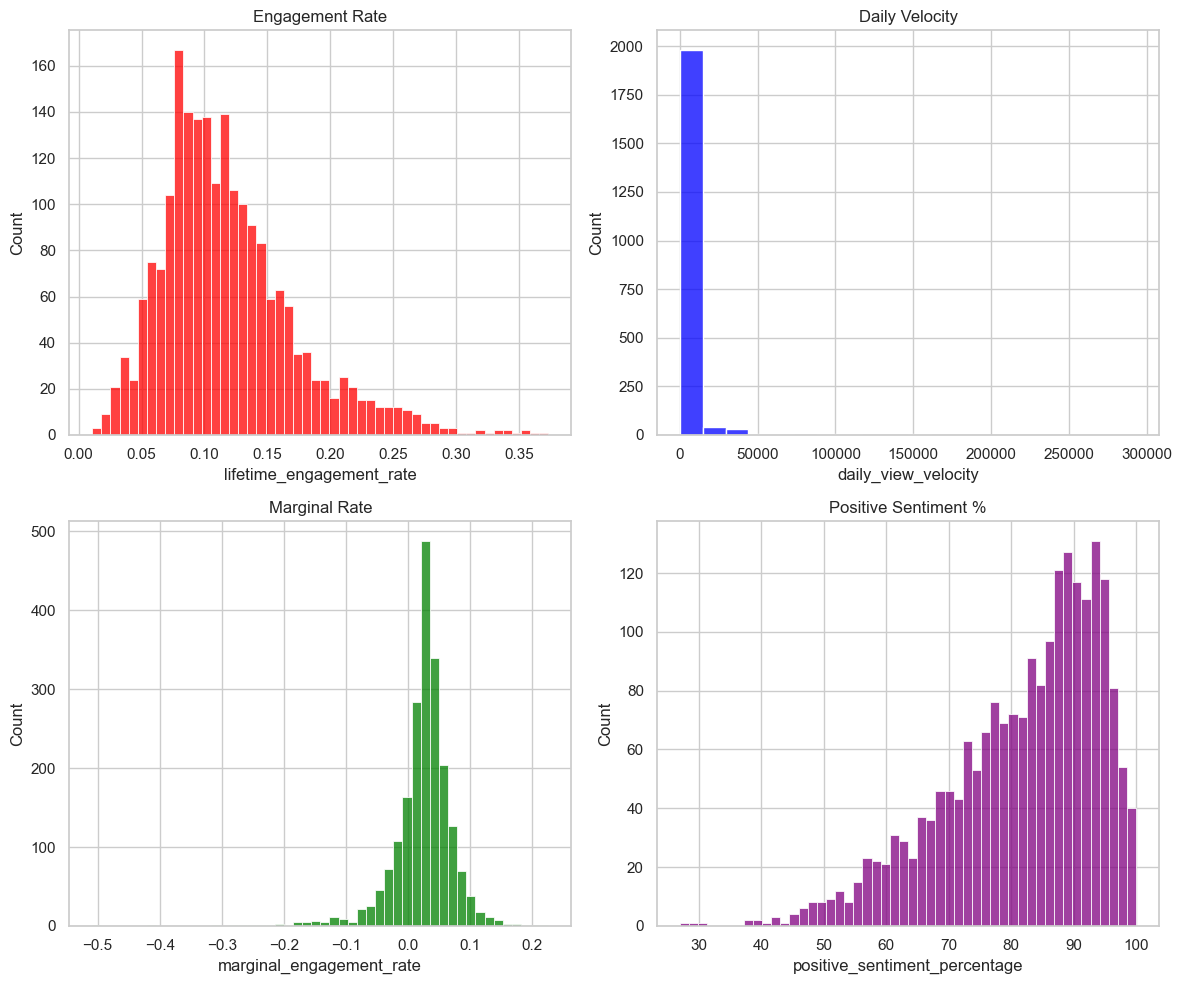

In [31]:
# Set the visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot distributions
sns.histplot(df, x="lifetime_engagement_rate", bins=50, ax=axes[0,0], color="red").set_title("Engagement Rate")
sns.histplot(df, x="daily_view_velocity", bins=20, ax=axes[0,1], color="blue").set_title("Daily Velocity")
sns.histplot(df, x="marginal_engagement_rate", bins=50, ax=axes[1,0], color="green").set_title("Marginal Rate")
sns.histplot(df, x="positive_sentiment_percentage", bins=50, ax=axes[1,1], color="purple").set_title("Positive Sentiment %")

plt.tight_layout()
plt.show()

## Normality Test

In [32]:
# Select only numeric columns
numerical_cols = ["video_age_days", "lifetime_engagement_rate", 
                  "marginal_engagement_rate", "daily_view_velocity", "positive_sentiment_percentage"]

col_name_list, stat_val_list, p_val_list, is_norm_list = [], [], [], []
for col_name in numerical_cols:
    jb_result = jarque_bera(df[col_name].dropna())
    stat_val = jb_result.statistic # type: ignore
    p_val = jb_result.pvalue # type: ignore
    if p_val <= 0.05:
        is_norm_list.append(False)
    else:
        is_norm_list.append(True)
    
    col_name_list.append(col_name)
    stat_val_list.append(stat_val)
    p_val_list.append(p_val)
    
normality_result = pd.DataFrame({
    "column": col_name_list,
    "stat_value": stat_val_list,
    "p_value": p_val_list,
    "is_norm": is_norm_list
})

normality_result

,column,stat_value,p_value,is_norm
0,video_age_days,2.474825e+02,1.819091e-54,False
1,lifetime_engagement_rate,7.164705e+02,2.632711e-156,False
2,marginal_engagement_rate,1.920589e+04,0.000000e+00,False
3,daily_view_velocity,1.231984e+06,0.000000e+00,False
4,positive_sentiment_percentage,3.124889e+02,1.392822e-68,False


***Note:*** 
* `daily_view_velocity` is heavily clumped to the left with a long tail to the right (right-skewed) due to some videos just being released and having a high number of views in the first few days, while most videos have a much lower daily view velocity. A future Machine Learning model will struggle to predict it.
* None of the numeric columns follow a normal distribution, and thus, a transformation is probably needed to make them more normally distributed.
* Apply a Log Transformation to these numeric columns when moving to the modeling phase.

# Categorical Deep Dive
*Which content pillars perform best?*

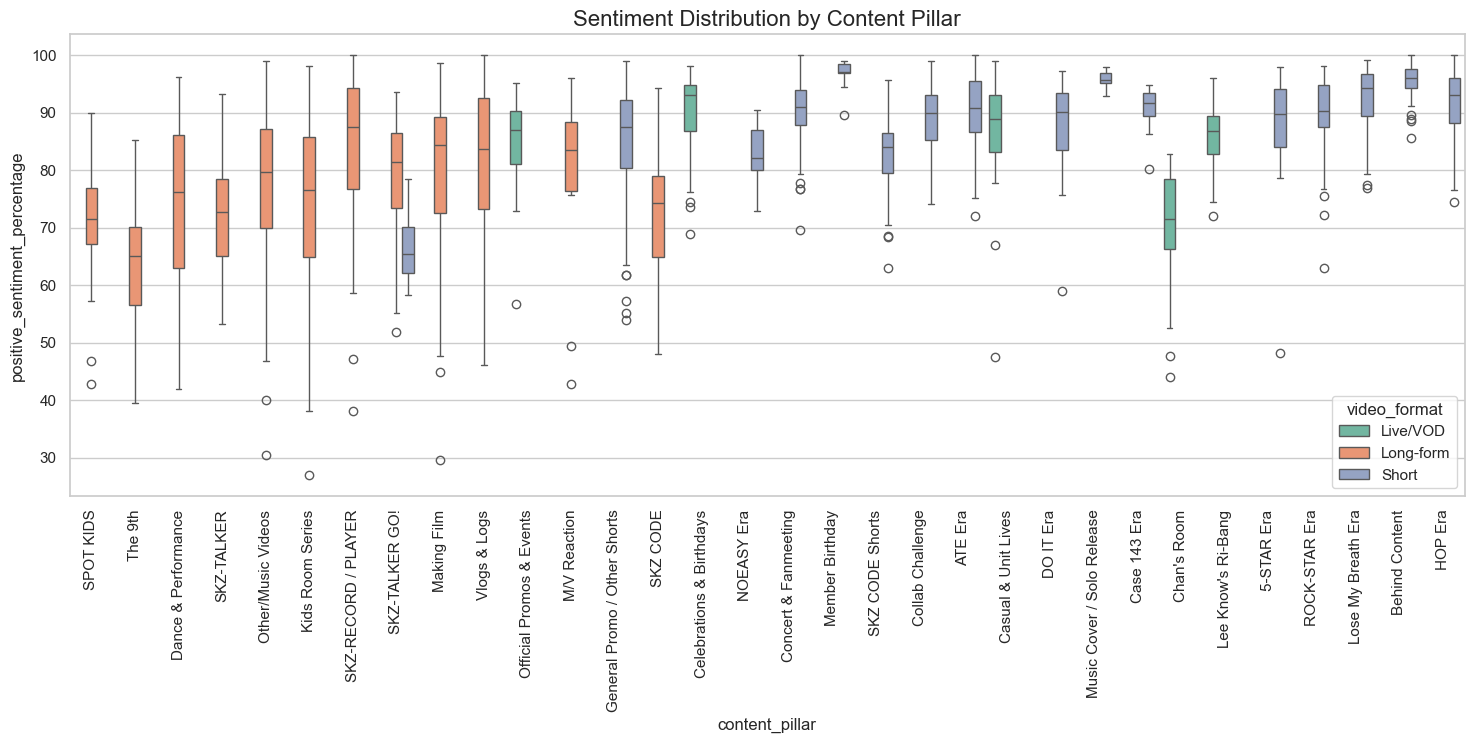

In [33]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x="content_pillar", y="positive_sentiment_percentage", palette="Set2", hue="video_format")
plt.title("Sentiment Distribution by Content Pillar", fontsize=16)
plt.xticks(rotation=90)
plt.show()

***Note:*** `SKZ-RECORD/PLAYER` and `Vlogs & Logs` videos show higher positive sentiment percentage compared to other long-form videos, which could be due to the fact that fans are more excited and emotionally connected to these types of content, leading to more positive interactions in the comments.

In [12]:
df["video_age_cohort"].unique()

['Legacy (2+ Years)', 'Catalog (6-24 Months)', 'Recent (1-6 Months)', 'New Release (<30 Days)']
Categories (4, str): ['New Release (<30 Days)', 'Recent (1-6 Months)', 'Catalog (6-24 Months)', 'Legacy (2+ Years)']

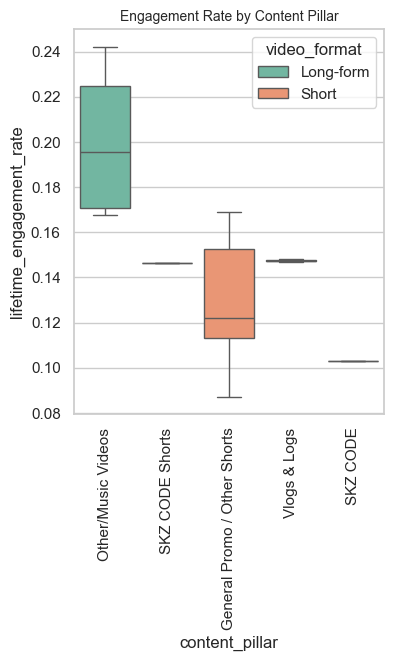

In [34]:
plt.figure(figsize=(4, 5))
sns.boxplot(
    data=df[df["video_age_cohort"] == "New Release (<30 Days)"].astype({
        "video_format": "str", "video_age_cohort": "str", "content_pillar": "str"
    }),
    x="content_pillar",
    y="lifetime_engagement_rate",
    palette="Set2",
    hue="video_format"
)
plt.title("Engagement Rate by Content Pillar", fontsize=10)
plt.xticks(rotation=90)
plt.show()

# Bivariate Analysis

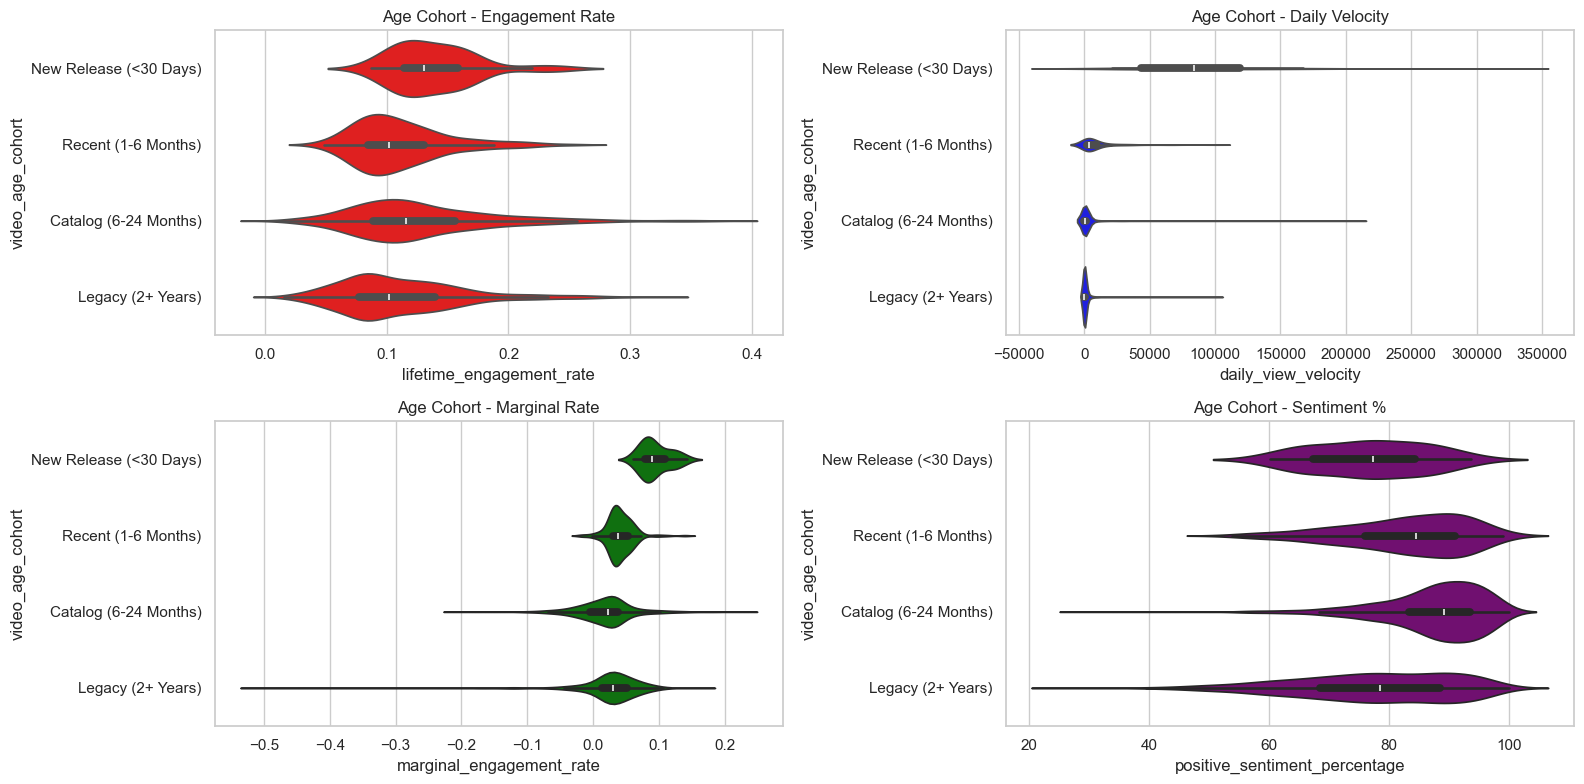

In [35]:
# Set the visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

sns.violinplot(df, x="lifetime_engagement_rate", y="video_age_cohort", ax=axes[0,0], color="red").set_title("Age Cohort - Engagement Rate")
sns.violinplot(df, x="daily_view_velocity", y="video_age_cohort", ax=axes[0,1], color="blue").set_title("Age Cohort - Daily Velocity")
sns.violinplot(df, x="marginal_engagement_rate", y="video_age_cohort", ax=axes[1,0], color="green").set_title("Age Cohort - Marginal Rate")
sns.violinplot(df, x="positive_sentiment_percentage", y="video_age_cohort", ax=axes[1,1], color="purple").set_title("Age Cohort - Sentiment %")

plt.tight_layout()
plt.show()

In [38]:
# Filter old videos that have high marginal rates relative to the new videos' average marginal ratio
recent_avg_marginal_ratio = df[df["video_age_cohort"] == "New Release (<30 Days)"].astype({"video_age_cohort": "str"})["marginal_engagement_rate"].mean()

df[(df["video_age_cohort"] == "Legacy (2+ Years)") & (df["marginal_engagement_rate"] >= recent_avg_marginal_ratio)]

,video_id,title,video_format,content_pillar,publish_year,publish_month,video_age_cohort,video_age_days,lifetime_engagement_rate,marginal_engagement_rate,daily_view_velocity,positive_sentiment_percentage
125,Rj4rhKrQ7x0,💥💫🔦✌ #StrayKids #스트레이키즈 #방찬 #BangChan #현진 #Hyu...,Short,General Promo / Other Shorts,2024,6,Legacy (2+ Years),722,0.174644,0.124347,3041.338302,81.343284
523,Y5yvC_NEjT4,[SPOT KIDS : BLACK] 긴박한 현장의 Stray Kids와 명사수 현진!,Long-form,SPOT KIDS,2018,1,Legacy (2+ Years),3074,0.153716,0.105820,52.120450,67.142857
528,sYEL-L3jDpM,[SPOT KIDS : BLACK] Stray Kids 멤버들의 셀카 비법 전수 타임!,Long-form,SPOT KIDS,2018,4,Legacy (2+ Years),2982,0.140201,0.097152,20.579305,68.571429
532,cbAi_0kzqvE,[SPOT KIDS : BLACK] 비니지니의 초!밀착 Talk (feat. 아무말파티),Long-form,SPOT KIDS,2018,6,Legacy (2+ Years),2929,0.145475,0.112523,18.993630,76.811594
558,6IKQjkR05Vs,[SPOT KIDS : BLACK] SKZ&SKZ(슼과 슼) Teaser Behin...,Long-form,SPOT KIDS,2018,12,Legacy (2+ Years),2737,0.122329,0.099415,11.789082,73.846154
655,STDBI3xPhtU,[SPOT KIDS : BLACK] Stray Kids의 혼란 속 가위바-보,Long-form,SPOT KIDS,2018,5,Legacy (2+ Years),2962,0.126663,0.094737,26.198110,73.437500
657,oLvoI2C_OFQ,[SPOT KIDS : BLACK] 꼼지락꼼지락 Stray Kids의 눕방 비하인드!,Long-form,SPOT KIDS,2018,6,Legacy (2+ Years),2935,0.130301,0.095683,29.541816,82.089552
665,Cw5U39pu5nU,[SPOT KIDS : BLACK] 알콩달콩 슼둥이들의 리얼한 대기실 모습 대공개!,Long-form,SPOT KIDS,2018,10,Legacy (2+ Years),2800,0.136364,0.098280,14.029782,75.714286
675,7_J-cnAvMmA,[Stray Kids : SKZ&SKZ(슼과 슼)] Ep.04,Long-form,Other/Music Videos,2018,11,Legacy (2+ Years),2760,0.098217,0.094180,32.575293,84.507042
775,7Yz183XU64E,"[SPOT KIDS : BLACK] 세상 신난 삼뿜이들의 ""뿜뿜"" 촬영가는 길♬",Long-form,SPOT KIDS,2018,6,Legacy (2+ Years),2915,0.148126,0.097070,18.821274,87.179487


In [39]:
# Filter old videos that have high engagement rates relative to the new videos' average engagement rate
recent_avg_eng_rate = df[df["video_age_cohort"] == "New Release (<30 Days)"].astype({"video_age_cohort": "str"})["lifetime_engagement_rate"].mean()

df[(df["video_age_cohort"] == "Legacy (2+ Years)") & (df["lifetime_engagement_rate"] >= recent_avg_eng_rate)]

,video_id,title,video_format,content_pillar,publish_year,publish_month,video_age_cohort,video_age_days,lifetime_engagement_rate,marginal_engagement_rate,daily_view_velocity,positive_sentiment_percentage
1,Ud7ublcLVic,🧊🧊 얼어붙은 한강 위로 빈냥이가 🏃🚶🏃🚶 #StrayKids #스트레이키즈 #창빈...,Short,General Promo / Other Shorts,2024,5,Legacy (2+ Years),760,0.180768,-0.026660,129.301418,94.339623
2,aPCGcMW6K0c,'Cause when our 👀 lock💙 #StrayKids #스트레이키즈 #필릭...,Short,Lose My Breath Era,2024,5,Legacy (2+ Years),758,0.181212,0.061806,499.728780,89.090909
3,8cbTLS3BxEc,🤙🤙🖤 #StrayKids #스트레이키즈 #방찬 #BangChan #창빈 #Chan...,Short,General Promo / Other Shorts,2024,5,Legacy (2+ Years),757,0.199431,-0.051516,117.098618,90.090090
4,7TS_xH853DI,"🎬""Lose My Breath (Feat. Charlie Puth)"" M/V Beh...",Short,Lose My Breath Era,2024,5,Legacy (2+ Years),755,0.205404,0.034976,248.364893,98.850575
5,1G5TlgNrQuw,"🎬""Lose My Breath (Feat. Charlie Puth)"" M/V Beh...",Short,Lose My Breath Era,2024,5,Legacy (2+ Years),755,0.260497,-0.004846,113.823855,97.058824
...,...,...,...,...,...,...,...,...,...,...,...,...
2056,2mjcFCkQbmU,🫧🎧😰➡🤘🐺🎶 #StrayKids #스트레이키즈 #樂_STAR #ROCK_STAR ...,Short,ROCK-STAR Era,2023,11,Legacy (2+ Years),935,0.198208,-0.015883,106.342896,94.252874
2057,oe_QQuvXClg,💧🎧😱➡🤘🐥🎵 #StrayKids #스트레이키즈 #樂_STAR #ROCK_STAR ...,Short,ROCK-STAR Era,2023,11,Legacy (2+ Years),935,0.159440,-0.055034,106.480780,90.000000
2059,QccmqBsw5BE,#현진 의 #락챌린지 #LALALALA_Challenge 🤘 w/ #윤찬영 #YOO...,Short,ROCK-STAR Era,2023,11,Legacy (2+ Years),934,0.152592,0.098550,211.617193,86.170213
2076,k2AaBG4muP0,Stray Kids가 전하는 2024 설날 인사💙 새해 복 많이 받으세요🙇,Long-form,Other/Music Videos,2024,2,Legacy (2+ Years),856,0.183526,-0.105263,17.683702,88.888889


***Note:***
* There are old videos like "Legacy (2+ Years)" with `marginal_ratio` that is significantly above the recent average. This signals old music videos or variety shows going viral again due to a trend, meme, or recent comeback mention.
* 

# Multivariate Analysis

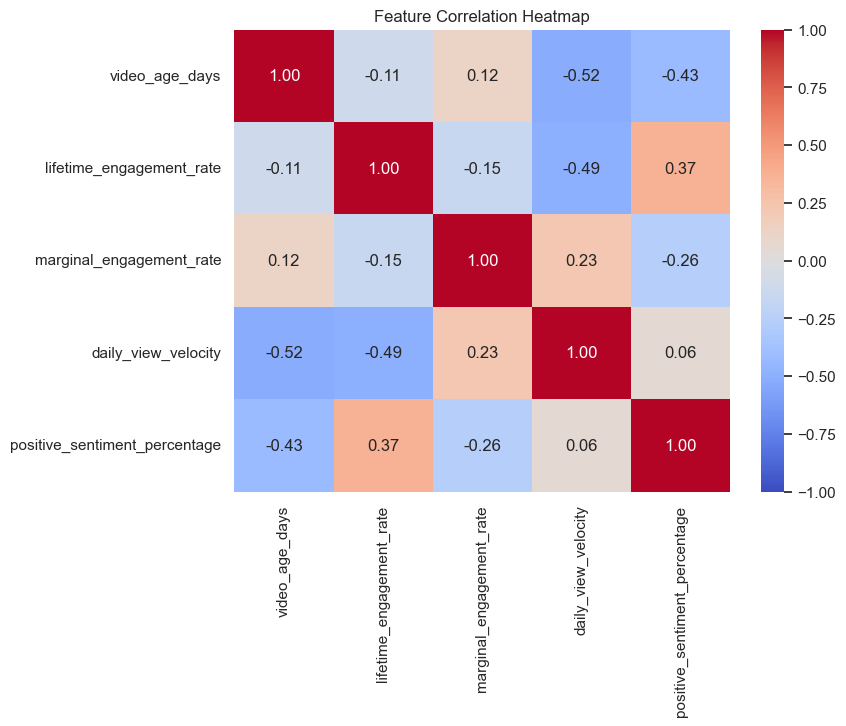

In [41]:
# Select only numerical columns
numerical_cols = ["video_age_days", "lifetime_engagement_rate", 
                  "marginal_engagement_rate", "daily_view_velocity", "positive_sentiment_percentage"]

corr_matrix = df[numerical_cols].dropna().corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

****Note:*** Features tend to have very low to moderate correlation with each other, which is good for Machine Learning models as it reduces the risk of multicollinearity.

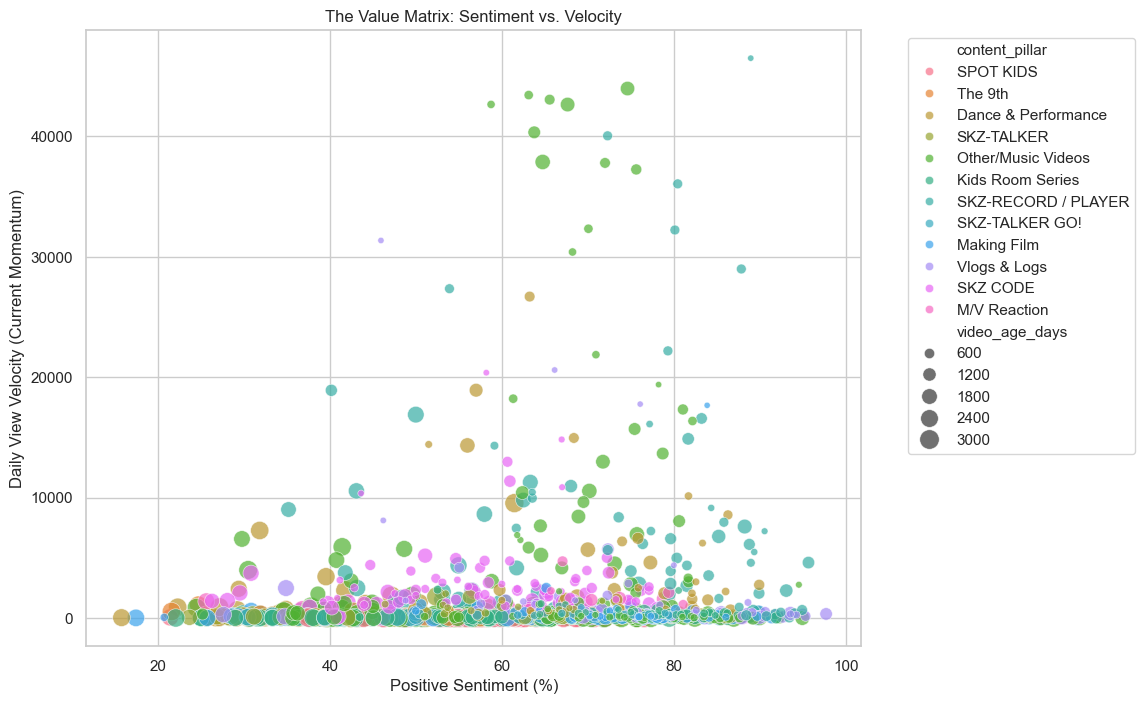

In [14]:
df_scattered = df[(df["video_format"] == "Long-form") & (df["daily_view_velocity"] <= 50000)].astype({"content_pillar": "str"})

plt.figure(figsize=(10, 8))
sns.scatterplot(x='positive_sentiment_percentage', 
                y='daily_view_velocity', 
                hue='content_pillar', 
                size='video_age_days',
                sizes=(20, 200),
                alpha=0.7,
                data=df_scattered)

plt.title('The Value Matrix: Sentiment vs. Velocity')
plt.xlabel('Positive Sentiment (%)')
plt.ylabel('Daily View Velocity (Current Momentum)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [42]:
df_sentiment_result[df_sentiment_result["sentiment_label"] == "negative"].sample(10)

,video_id,comment_id,text,language,sentiment_label
56317,MI6_aH1JT7s,Ugx0tsbzuxQZBPYZurh4AaABAg,The editors are so diabolical at one point dur...,eng_Latn,negative
159026,XHZJY-H-I7U,UgyyVGY3pG6AaSEg4Ox4AaABAg,chan be like: its so hard being a solo parent ...,eng_Latn,negative
63619,To0w8Qh7kVo,Ugx9UKTJb728qd129lt4AaABAg,すんちゃんの涙見て胸がキュッとなった😥\n泣かずに見る自信がないわー😢,jpn_Jpan,negative
67744,lhgbl7ENZSY,UgxcD39KGF0VP-pGBGF4AaABAg,살벌하게 생겼다 이리노,kor_Hang,negative
35656,x-kl7fzEmaY,UgwP8QLOanpiLWqeDER4AaABAg,HOW DARE YOUTUBE HIDING THIS 3 MINUTES?!?!,yue_Hant,negative
181926,lldrm_7fVP0,UgzgI5N4NHVRj-2VZj94AaABAg,콘서트 가고 싶다ㅜ,kor_Hang,negative
70326,vPTFGiybrzA,UgxDUcxR2nhpSaJihal4AaABAg,but it must be soo uncomfortable for them cuz ...,eng_Latn,negative
161897,dtV1I9WtQuo,Ugz_2RIEpvs93NniW-B4AaABAg,"when I listened to it, it was ""three minutes"" ...",eng_Latn,negative
213041,bY_TqcsMyHM,Ugzz6i9AHnCMHoQlSr54AaABAg,Girls dont want boyfriend they just want hyunj...,eng_Latn,negative
193870,qqUKjw5-JSQ,UgznnWXfU-YMDWM_cb94AaABAg,WE NEED MORE DANCER LEEKNOW CONTENT 💔,yue_Hant,negative


In [25]:
df_sentiment_result[df_sentiment_result["sentiment_label"] == "negative"].sample(10)

,video_id,comment_id,text,language,sentiment_label
56549,5W-TgonoJxk,Ugx4N3kPZx8eFtHsevR4AaABAg,Han is really a comedian in his past life😭😭😭,eng_Latn,negative
56791,mYAmqZP2P8Q,Ugx4wnYsgijatdG8j0N4AaABAg,Minho and Han accepting their fate to be toget...,eng_Latn,negative
35237,COXxhiCpLwE,UgwpViromoDMk2slkc14AaABAg,I.n being treated like a princess at the end 😭😭😭,eng_Latn,negative
191036,wICmykm0MDQ,UgzrwlJcghHfOUtZpiN4AaABAg,I’m sorry Hyunjin but you need to fire whoever...,eng_Latn,negative
109831,KfUfcBPLteg,Ugy7TE-oa3tFPUV9KkN4AaABAg,I ALMOST IGNORED THE NOTIFICATION BECAUSE OF T...,yue_Hant,negative
22751,-I3qCp_fFJ4,UgwI5WZLFOeSQ4Z4Clt4AaABAg,2:58 HYUNJIN STANS HOW WE DOING?? T_T the dis...,kor_Hang,negative
154671,TVNTsUcBank,Ugz_zcULljBaT0HZu-Z4AaABAg,I just finished watching the episode and almos...,eng_Latn,negative
38210,fp1x-Db_I0Q,UgwRQbLFKcHIQ7s7P5N4AaABAg,i will cry to this video when hyunjin has to g...,eng_Latn,negative
122001,RQDj6OIb6ik,Ugygml8yE1_FrxAl14p4AaABAg,CHANGBINS FACE I CANT OMLLLL,yue_Hant,negative
65032,SjKARrJwqzE,UgxCmhMgbIy6QZSkpQV4AaABAg,skz who released this as a joke watching it hi...,eng_Latn,negative
